# Decision tree classification

This notebook uses a **decision tree** to predict whether a person earns more than $50K per year from the Adult Income dataset (1994 US Census).

| Step | Task |
|---|---|
| 1 | Select the dataset |
| 2 | Data preparation (preprocessing) |
| 3 | Splitting the dataset |
| 4a | Decision trees of varying **depth**: select the best depth |
| 4b | Decision trees with varying **minimum samples in leaf nodes**: select the best value |
| 5 | Evaluate the final model with classification metrics and model characteristics |
| 5a | Visualise the results |
| 6 | *(Optional)* Induce decision rules from the tree and compare a rule-based classifier with the tree |

## Getting ready

Import libraries.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

RANDOM_STATE = 42
N_FOLDS = 5

print("Libraries loaded.")

Libraries loaded.


## 1. Dataset

**Adult Income dataset** (UCI Machine Learning Repository, 1994 US Census).

- **Task:** binary classification. Does a person earn more than $50K per year?
- **Target variable:** `income` (1 = >50K, 0 = ≤50K)
- **Predictors:** age, years of education, work class, occupation, hours per week, capital gain and loss, marital status, relationship, race, gender and country of origin
- **Size:** about 30,000 training and 15,000 test observations after cleaning

## 2. Data preparation (preprocessing)

The data was already cleaned and encoded in the descriptive statistics notebook and saved to `processed_data`:

- Rows with missing values (`?`) were removed.
- The `.` at the end of the test labels (`>50K.`) was removed so train and test labels match.
- Categorical variables were encoded: `gender` → 0/1, `native_country` → `is_us` 0/1, and the other categorical variables were one-hot encoded.
- `education` was dropped because `education_num` contains the same information, and `fnlwgt` was dropped because it is a census sampling weight.

**Decision trees do not need feature scaling**, because each split compares one variable with a threshold, so the scale of the variable does not matter. No further transformation is needed.

In [24]:
train = pd.read_csv("C:/Users/gabij/OneDrive/Desktop/processed_data/train_encoded.csv")
test = pd.read_csv("C:/Users/gabij/OneDrive/Desktop/processed_data/test_encoded.csv")

# Safety checks: remove an index column (if saved with the index) and any leftover helper column
extra_columns = [c for c in train.columns if c.startswith("Unnamed") or c == "education_te"]
train = train.drop(columns=extra_columns)
test = test.drop(columns=extra_columns, errors="ignore")

print("Training shape:", train.shape)  # expected about (30162, 42): 41 predictors + income
print("Test shape:    ", test.shape)  # expected about (15060, 42)
print("Missing values (train):", train.isna().sum().sum())
print("Missing values (test): ", test.isna().sum().sum())
print("Income values:", sorted(train["income"].unique().tolist()))

display(train.head())
# Safety checks: remove an index column (if saved with the index) and any leftover helper column
extra_columns = [c for c in train.columns if c.startswith("Unnamed") or c == "education_te"]
train = train.drop(columns=extra_columns)
test = test.drop(columns=extra_columns, errors="ignore")

# Remove any remaining missing values
train = train.dropna().reset_index(drop=True)
test = test.dropna().reset_index(drop=True)

X_train = train.drop(columns="income")
y_train = train["income"].astype(int)

X_test = test.drop(columns="income").reindex(columns=X_train.columns, fill_value=0)
y_test = test["income"].astype(int)

feature_names = X_train.columns.tolist()

print("Training set:", X_train.shape)    # expected about (30162, 41)
print("Test set:    ", X_test.shape)     # expected about (15060, 41)
print("Missing values:", X_train.isna().sum().sum() + X_test.isna().sum().sum())
print("Non-numeric columns:", X_train.select_dtypes(exclude="number").columns.tolist())

display(X_train.head())

Training shape: (32561, 43)
Test shape:     (16281, 43)
Missing values (train): 0
Missing values (test):  0
Income values: [0, 1]


,age,education_num,gender,capital_gain,capital_loss,hours_per_week,is_us,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,income
0,39,13,1,2174,0,40,1,0,0,0,...,1,0,0,0,0,0,0,0,1,0
1,50,13,1,0,0,13,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,38,9,1,0,0,40,1,0,0,1,...,1,0,0,0,0,0,0,0,1,0
3,53,7,1,0,0,40,1,0,0,1,...,0,0,0,0,0,0,1,0,0,0
4,28,13,0,0,0,40,0,0,0,1,...,0,0,0,0,1,0,1,0,0,0


Training set: (32561, 42)
Test set:     (16281, 42)
Missing values: 0
Non-numeric columns: []


,age,education_num,gender,capital_gain,capital_loss,hours_per_week,is_us,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,39,13,1,2174,0,40,1,0,0,0,...,0,1,0,0,0,0,0,0,0,1
1,50,13,1,0,0,13,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,38,9,1,0,0,40,1,0,0,1,...,0,1,0,0,0,0,0,0,0,1
3,53,7,1,0,0,40,1,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,28,13,0,0,0,40,0,0,0,1,...,0,0,0,0,0,1,0,1,0,0


#### Target variable distribution

In [25]:
class_summary = pd.DataFrame({
    "Train count": y_train.value_counts().sort_index(),
    "Train (%)": y_train.value_counts(normalize=True).sort_index().mul(100),
    "Test count": y_test.value_counts().sort_index(),
    "Test (%)": y_test.value_counts(normalize=True).sort_index().mul(100)
})
class_summary.index = ["<=50K (0)", ">50K (1)"]
display(class_summary.round(2))

print("The classes are imbalanced (about 75% / 25%), so accuracy alone can be misleading.")
print("The F1-score for the >50K class is used to select the best tree settings.")

,Train count,Train (%),Test count,Test (%)
<=50K (0),24720,75.92,16281.0,100.0
>50K (1),7841,24.08,NaN,NaN


The classes are imbalanced (about 75% / 25%), so accuracy alone can be misleading.
The F1-score for the >50K class is used to select the best tree settings.


## 3. Splitting the dataset

Two levels of splitting are used:

1. **Hold-out test set:** the dataset comes with a separate test file (`adult.test`), which is used **only once**, for the final evaluation of the chosen model.
2. **Stratified 5-fold cross-validation on the training set:** used to compare trees with different settings. The training data is split into 5 parts. Each tree is trained on 4 parts and evaluated on the 5th, five times, and the results are averaged. *Stratified* means every fold keeps the same 75% / 25% class ratio.

This way the tree settings are chosen without looking at the test set, so the final test result is an honest estimate of performance on new data.

In [26]:
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# zero_division=0: a very shallow tree may never predict >50K; precision is then reported as 0
scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
}

print("Fold sizes and share of >50K in each validation fold:")
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):
    print(f"Fold {fold}: train = {len(train_idx)}, validation = {len(val_idx)}, "
          f">50K share = {y_train.iloc[val_idx].mean():.3f}")


def evaluate_tree(**tree_params):
    """Cross-validate a decision tree with the given settings and return mean scores."""
    tree = DecisionTreeClassifier(random_state=RANDOM_STATE, **tree_params)
    scores = cross_validate(tree, X_train, y_train, cv=cv, scoring=scoring,
                            return_train_score=True)
    result = {name: scores[f"test_{name}"].mean() for name in scoring}
    result["train_f1"] = scores["train_f1"].mean()
    result["train_accuracy"] = scores["train_accuracy"].mean()
    result["f1_std"] = scores["test_f1"].std()
    return result

Fold sizes and share of >50K in each validation fold:
Fold 1: train = 26048, validation = 6513, >50K share = 0.241
Fold 2: train = 26049, validation = 6512, >50K share = 0.241
Fold 3: train = 26049, validation = 6512, >50K share = 0.241
Fold 4: train = 26049, validation = 6512, >50K share = 0.241
Fold 5: train = 26049, validation = 6512, >50K share = 0.241


## 4a. Decision trees of varying depth

`max_depth` limits how many questions the tree can ask before making a decision.
- **Too shallow** → the tree is too simple and misses patterns (underfitting).
- **Too deep** → the tree memorises the training data, including noise (overfitting).

All other settings are left at their defaults.

In [27]:
depths = list(range(1, 26)) + [None]

depth_results = []
for depth in depths:
    result = evaluate_tree(max_depth=depth)
    result["max_depth"] = "None" if depth is None else depth
    depth_results.append(result)

depth_results = pd.DataFrame(depth_results).set_index("max_depth")

display(depth_results[["train_accuracy", "accuracy", "train_f1", "f1", "precision", "recall", "roc_auc"]]
        .rename(columns={"accuracy": "cv_accuracy", "f1": "cv_f1", "precision": "cv_precision",
                         "recall": "cv_recall", "roc_auc": "cv_roc_auc"})
        .round(4))

,train_accuracy,cv_accuracy,train_f1,cv_f1,cv_precision,cv_recall,cv_roc_auc
max_depth,,,,,,,
1,0.7592,0.7592,0.0000,0.0000,0.0000,0.0000,0.7592
2,0.8282,0.8282,0.5568,0.5568,0.7353,0.4482,0.8313
3,0.8439,0.8439,0.6133,0.6132,0.7601,0.5140,0.8580
4,0.8441,0.8437,0.6147,0.6136,0.7586,0.5152,0.8730
5,0.8493,0.8479,0.6233,0.6201,0.7784,0.5155,0.8853
6,0.8564,0.8541,0.6447,0.6386,0.7910,0.5355,0.8952
7,0.8591,0.8554,0.6504,0.6414,0.7967,0.5369,0.9012
8,0.8611,0.8562,0.6583,0.6458,0.7936,0.5444,0.9048
9,0.8651,0.8549,0.6907,0.6669,0.7478,0.6062,0.9032


Best max_depth (highest cross-validated F1) = 11


,accuracy,precision,recall,f1,roc_auc
max_depth,,,,,
11,0.856,0.7537,0.6016,0.6674,0.8929


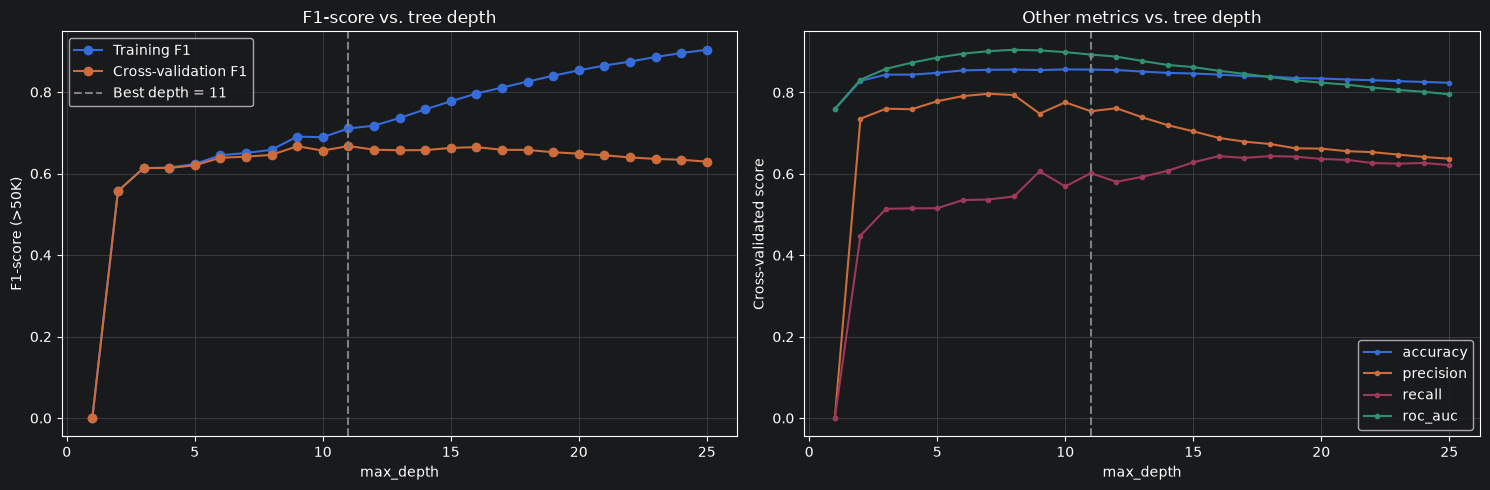

In [28]:
best_depth = depth_results["f1"].idxmax()
print(f"Best max_depth (highest cross-validated F1) = {best_depth}")
display(depth_results.loc[[best_depth], ["accuracy", "precision", "recall", "f1", "roc_auc"]].round(4))

numeric_depths = depth_results.drop(index="None")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(numeric_depths.index, numeric_depths["train_f1"], marker="o", label="Training F1")
axes[0].plot(numeric_depths.index, numeric_depths["f1"], marker="o", label="Cross-validation F1")
axes[0].axvline(best_depth, color="grey", linestyle="--", label=f"Best depth = {best_depth}")
axes[0].set_xlabel("max_depth")
axes[0].set_ylabel("F1-score (>50K)")
axes[0].set_title("F1-score vs. tree depth")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for metric in ["accuracy", "precision", "recall", "roc_auc"]:
    axes[1].plot(numeric_depths.index, numeric_depths[metric], marker=".", label=metric)
axes[1].axvline(best_depth, color="grey", linestyle="--")
axes[1].set_xlabel("max_depth")
axes[1].set_ylabel("Cross-validated score")
axes[1].set_title("Other metrics vs. tree depth")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation:** training F1 keeps rising as the tree gets deeper, until the tree fits the training data almost perfectly. Cross-validation F1 rises at first, reaches a peak, then falls. To the right of the peak the tree is **overfitting**: it learns patterns that exist only in the training data and do not generalise. The best depth is where the cross-validation score is highest.

## 4b. Decision trees with varying numbers of samples in the leaf nodes

`min_samples_leaf` is the minimum number of training observations every leaf must contain. A leaf with very few people produces a decision based on a handful of cases, which is unreliable. Larger values make the tree simpler and more stable.

Here the depth is **not** limited, so the effect of `min_samples_leaf` alone can be seen.

In [29]:
leaf_sizes = [1, 2, 5, 10, 15, 20, 30, 50, 75, 100, 150, 200, 300, 500, 750, 1000]

leaf_results = []
for leaf_size in leaf_sizes:
    result = evaluate_tree(min_samples_leaf=leaf_size)
    result["min_samples_leaf"] = leaf_size
    leaf_results.append(result)

leaf_results = pd.DataFrame(leaf_results).set_index("min_samples_leaf")

display(leaf_results[["train_accuracy", "accuracy", "train_f1", "f1", "precision", "recall", "roc_auc"]]
        .rename(columns={"accuracy": "cv_accuracy", "f1": "cv_f1", "precision": "cv_precision",
                         "recall": "cv_recall", "roc_auc": "cv_roc_auc"})
        .round(4))

,train_accuracy,cv_accuracy,train_f1,cv_f1,cv_precision,cv_recall,cv_roc_auc
min_samples_leaf,,,,,,,
1,0.9785,0.8174,0.9540,0.6158,0.6243,0.6077,0.7656
2,0.9322,0.8326,0.8459,0.6186,0.6854,0.5638,0.8087
5,0.9023,0.8409,0.7827,0.6471,0.6948,0.6057,0.8638
10,0.8849,0.8517,0.7379,0.6614,0.7348,0.6015,0.8877
15,0.8783,0.8534,0.7233,0.6673,0.7362,0.6104,0.8960
20,0.8745,0.8559,0.7140,0.6722,0.7435,0.6134,0.8999
30,0.8702,0.8571,0.7039,0.6743,0.7477,0.6141,0.9042
50,0.8646,0.8575,0.6897,0.6726,0.7528,0.6080,0.9070
75,0.8611,0.8558,0.6776,0.6650,0.7550,0.5943,0.9073


Best min_samples_leaf (highest cross-validated F1) = 30


,accuracy,precision,recall,f1,roc_auc
min_samples_leaf,,,,,
30,0.8571,0.7477,0.6141,0.6743,0.9042


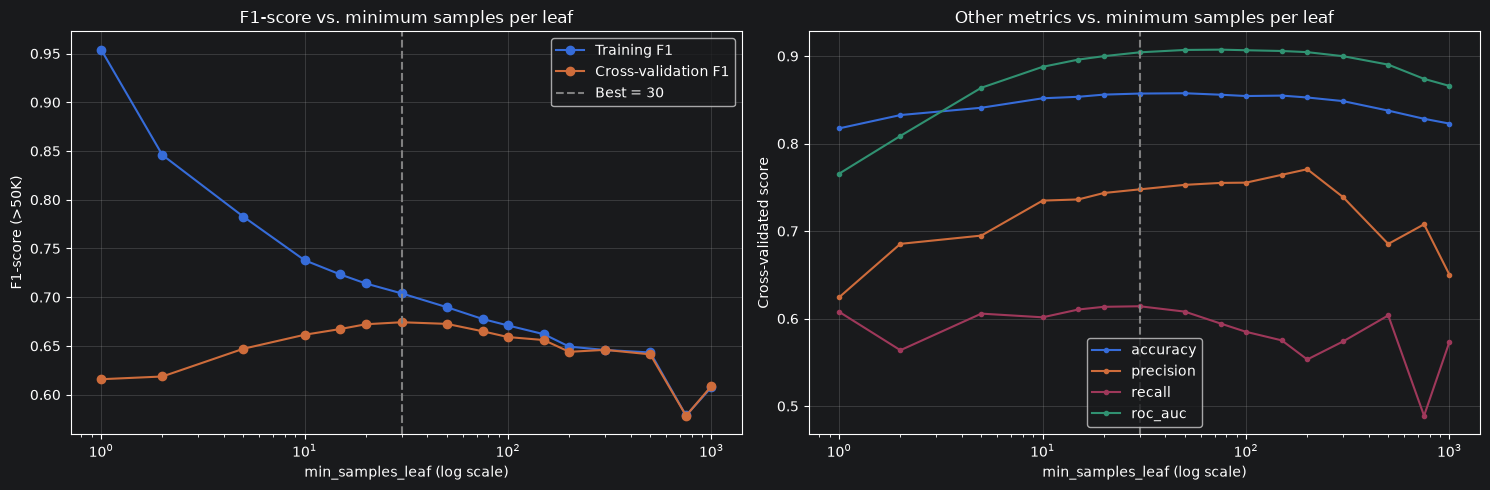

In [30]:
best_leaf = leaf_results["f1"].idxmax()
print(f"Best min_samples_leaf (highest cross-validated F1) = {best_leaf}")
display(leaf_results.loc[[best_leaf], ["accuracy", "precision", "recall", "f1", "roc_auc"]].round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(leaf_results.index, leaf_results["train_f1"], marker="o", label="Training F1")
axes[0].plot(leaf_results.index, leaf_results["f1"], marker="o", label="Cross-validation F1")
axes[0].axvline(best_leaf, color="grey", linestyle="--", label=f"Best = {best_leaf}")
axes[0].set_xscale("log")
axes[0].set_xlabel("min_samples_leaf (log scale)")
axes[0].set_ylabel("F1-score (>50K)")
axes[0].set_title("F1-score vs. minimum samples per leaf")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for metric in ["accuracy", "precision", "recall", "roc_auc"]:
    axes[1].plot(leaf_results.index, leaf_results[metric], marker=".", label=metric)
axes[1].axvline(best_leaf, color="grey", linestyle="--")
axes[1].set_xscale("log")
axes[1].set_xlabel("min_samples_leaf (log scale)")
axes[1].set_ylabel("Cross-validated score")
axes[1].set_title("Other metrics vs. minimum samples per leaf")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation:** with `min_samples_leaf = 1` the tree can create a leaf for every single person, so it overfits (high training score, lower cross-validation score). Increasing the value forces each decision to be based on more people, which reduces overfitting. If the value is too large, the tree becomes too coarse and starts to underfit.

#### Combining the two settings

Depth and leaf size both control tree complexity, so they interact. To build the final model, both are tuned together over a grid around the best values found above, again using cross-validation on the training set only.

Best combination: max_depth = None, min_samples_leaf = 30
Cross-validated F1 = 0.6743, accuracy = 0.8571


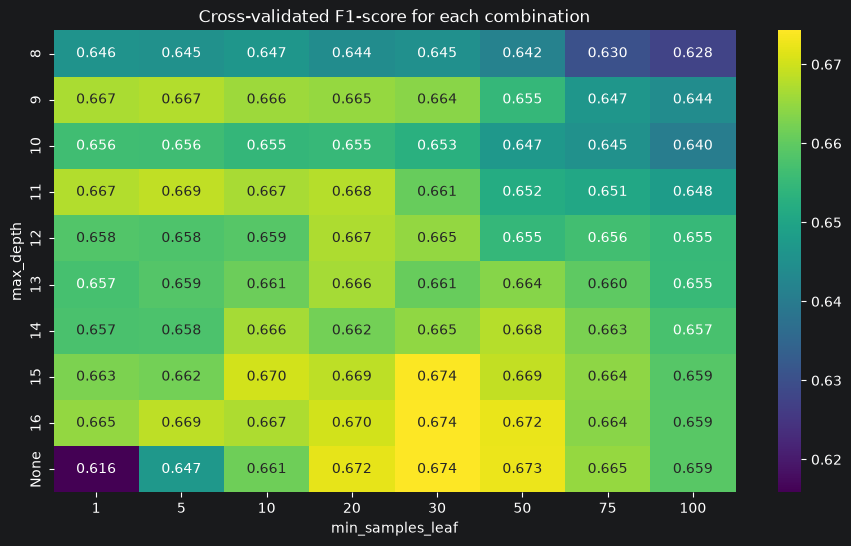

In [31]:
depth_grid = [d for d in range(max(2, best_depth - 3), best_depth + 6)] + [None]
leaf_grid = sorted(set([1, 5, 10, 20, 30, 50, 75, 100, best_leaf]))

combined_results = []
for depth in depth_grid:
    for leaf_size in leaf_grid:
        result = evaluate_tree(max_depth=depth, min_samples_leaf=leaf_size)
        result["max_depth"] = "None" if depth is None else depth
        result["min_samples_leaf"] = leaf_size
        combined_results.append(result)

combined_results = pd.DataFrame(combined_results)

best_row = combined_results.loc[combined_results["f1"].idxmax()]
final_depth = None if best_row["max_depth"] == "None" else int(best_row["max_depth"])
final_leaf = int(best_row["min_samples_leaf"])

print(f"Best combination: max_depth = {final_depth}, min_samples_leaf = {final_leaf}")
print(f"Cross-validated F1 = {best_row['f1']:.4f}, accuracy = {best_row['accuracy']:.4f}")

heatmap_data = combined_results.pivot(index="max_depth", columns="min_samples_leaf", values="f1")
heatmap_data = heatmap_data.reindex(["None" if d is None else d for d in depth_grid])

plt.figure(figsize=(11, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis")
plt.title("Cross-validated F1-score for each combination")
plt.xlabel("min_samples_leaf")
plt.ylabel("max_depth")
plt.show()

#### Comparison of the candidate models on the training data (cross-validation)

In [32]:
candidates = {
    "Default tree (no limits)": dict(),
    f"Best depth (max_depth={best_depth})": dict(max_depth=best_depth),
    f"Best leaf size (min_samples_leaf={best_leaf})": dict(min_samples_leaf=best_leaf),
    f"Final (max_depth={final_depth}, min_samples_leaf={final_leaf})": dict(max_depth=final_depth, min_samples_leaf=final_leaf),
}

candidate_results = pd.DataFrame({name: evaluate_tree(**params) for name, params in candidates.items()}).T
display(candidate_results[["train_accuracy", "accuracy", "precision", "recall", "f1", "roc_auc"]]
        .rename(columns={"accuracy": "cv_accuracy", "precision": "cv_precision", "recall": "cv_recall",
                         "f1": "cv_f1", "roc_auc": "cv_roc_auc"})
        .round(4))

,train_accuracy,cv_accuracy,cv_precision,cv_recall,cv_f1,cv_roc_auc
Default tree (no limits),0.9785,0.8174,0.6243,0.6077,0.6158,0.7656
Best depth (max_depth=11),0.8750,0.8560,0.7537,0.6016,0.6674,0.8929
Best leaf size (min_samples_leaf=30),0.8702,0.8571,0.7477,0.6141,0.6743,0.9042
"Final (max_depth=None, min_samples_leaf=30)",0.8702,0.8571,0.7477,0.6141,0.6743,0.9042


## 5. Final model: evaluation on the test set

The final tree is trained on the **whole training set** with the selected settings and evaluated **once** on the test set.

In [33]:
final_tree = DecisionTreeClassifier(
    max_depth=final_depth,
    min_samples_leaf=final_leaf,
    random_state=RANDOM_STATE
)
final_tree.fit(X_train, y_train)

y_prob_tree = final_tree.predict_proba(X_test)[:, 1]
y_pred_tree = final_tree.predict(X_test)

def classification_metrics(y_true, y_pred, y_prob=None):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_prob is not None:
        metrics["ROC-AUC"] = roc_auc_score(y_true, y_prob)
    return metrics

tree_metrics = classification_metrics(y_test, y_pred_tree, y_prob_tree)

display(pd.DataFrame(tree_metrics, index=["Decision tree (test set)"]).round(4))

print(f"Baseline accuracy (always predicting <=50K) = {1 - y_test.mean():.4f}")
print(f"Training accuracy = {final_tree.score(X_train, y_train):.4f}   Test accuracy = {tree_metrics['Accuracy']:.4f}")

C:\Users\gabij\PycharmProjects\WelcomeScreen\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Decision tree (test set),0.8119,0.0,0.0,0.0,NaN


Baseline accuracy (always predicting <=50K) = 1.0000
Training accuracy = 0.8708   Test accuracy = 0.8119


#### Classification report

In [34]:
print(classification_report(y_test, y_pred_tree, target_names=["No (<=50K)", "Yes (>50K)"], zero_division=0))

              precision    recall  f1-score   support

  No (<=50K)       1.00      0.81      0.90     16281
  Yes (>50K)       0.00      0.00      0.00         0

    accuracy                           0.81     16281
   macro avg       0.50      0.41      0.45     16281
weighted avg       1.00      0.81      0.90     16281



#### Model characteristics

In [35]:
characteristics = pd.DataFrame({
    "Value": [
        final_tree.get_depth(),
        final_tree.get_n_leaves(),
        final_tree.tree_.node_count,
        final_tree.tree_.node_count - final_tree.get_n_leaves(),
        int((final_tree.feature_importances_ > 0).sum()),
        len(feature_names),
    ]
}, index=[
    "Actual tree depth",
    "Number of leaves (= decision rules)",
    "Total number of nodes",
    "Number of internal (split) nodes",
    "Features used in at least one split",
    "Features available",
])
display(characteristics)

feature_importance = (pd.Series(final_tree.feature_importances_, index=feature_names)
                      .sort_values(ascending=False))
print("Top 10 most important features (share of total impurity reduction):")
display(feature_importance.head(10).round(4).to_frame("Importance"))

,Value
Actual tree depth,25
Number of leaves (= decision rules),552
Total number of nodes,1103
Number of internal (split) nodes,551
Features used in at least one split,32
Features available,42


Top 10 most important features (share of total impurity reduction):


,Importance
marital_status_Married-civ-spouse,0.3823
education_num,0.2117
capital_gain,0.1828
age,0.0652
capital_loss,0.0522
hours_per_week,0.0443
occupation_Exec-managerial,0.0111
workclass_Self-emp-not-inc,0.0078
occupation_Prof-specialty,0.0072
relationship_Wife,0.0050


## 5a. Visualisation of the results

#### Confusion matrix

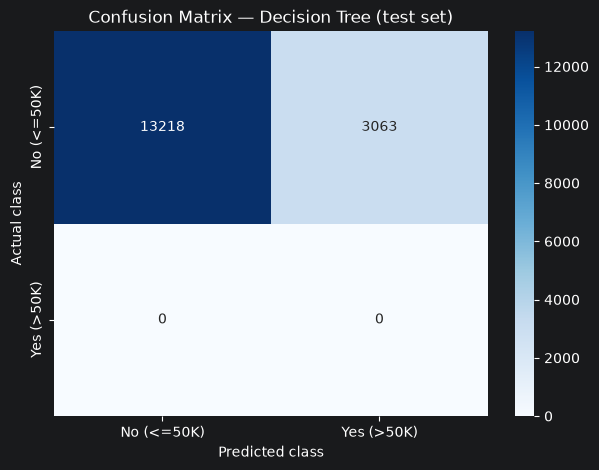

True negatives  (correctly predicted <=50K): 13218
False positives (predicted >50K, actually <=50K): 3063
False negatives (predicted <=50K, actually >50K): 0
True positives  (correctly predicted >50K): 0


In [36]:
cm = confusion_matrix(y_test, y_pred_tree, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No (<=50K)", "Yes (>50K)"],
            yticklabels=["No (<=50K)", "Yes (>50K)"])
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.title("Confusion Matrix — Decision Tree (test set)")
plt.show()

print(f"True negatives  (correctly predicted <=50K): {tn}")
print(f"False positives (predicted >50K, actually <=50K): {fp}")
print(f"False negatives (predicted <=50K, actually >50K): {fn}")
print(f"True positives  (correctly predicted >50K): {tp}")

#### ROC curve

C:\Users\gabij\PycharmProjects\WelcomeScreen\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1364: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


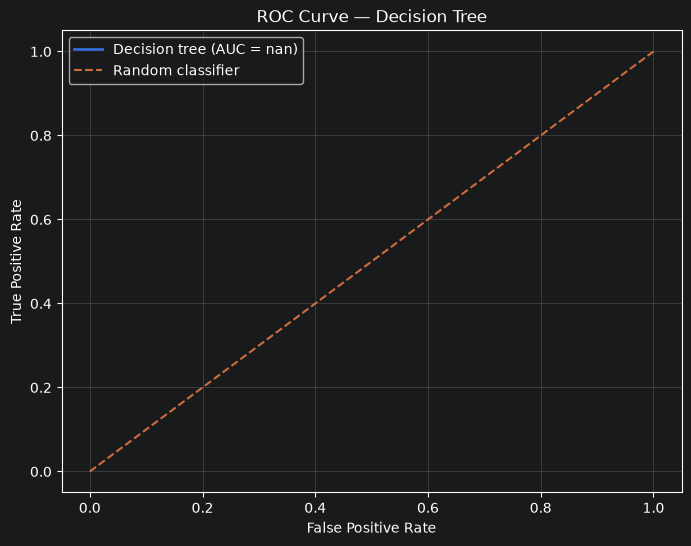

In [37]:
fpr, tpr, _ = roc_curve(y_test, y_prob_tree)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"Decision tree (AUC = {tree_metrics['ROC-AUC']:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Decision Tree")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Feature importance

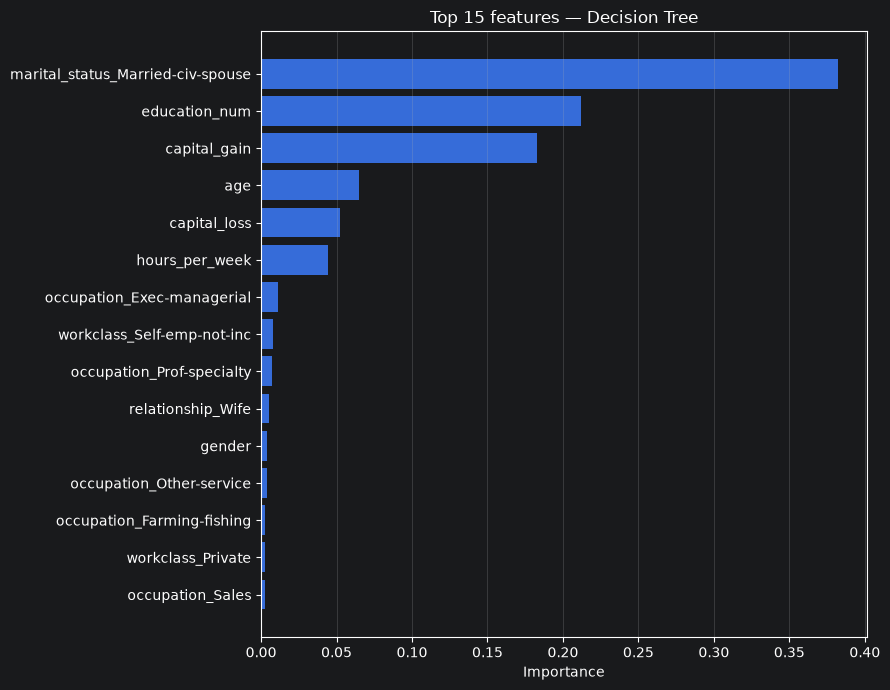

In [38]:
top_features = feature_importance.head(15).sort_values()

plt.figure(figsize=(9, 7))
plt.barh(top_features.index, top_features.values)
plt.xlabel("Importance")
plt.title("Top 15 features — Decision Tree")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

#### The decision tree (top levels)

The full tree is too large to read, so only the first 3 levels are drawn. Each box shows the split condition, the Gini impurity, the number of training samples, the class counts `[<=50K, >50K]` and the majority class.

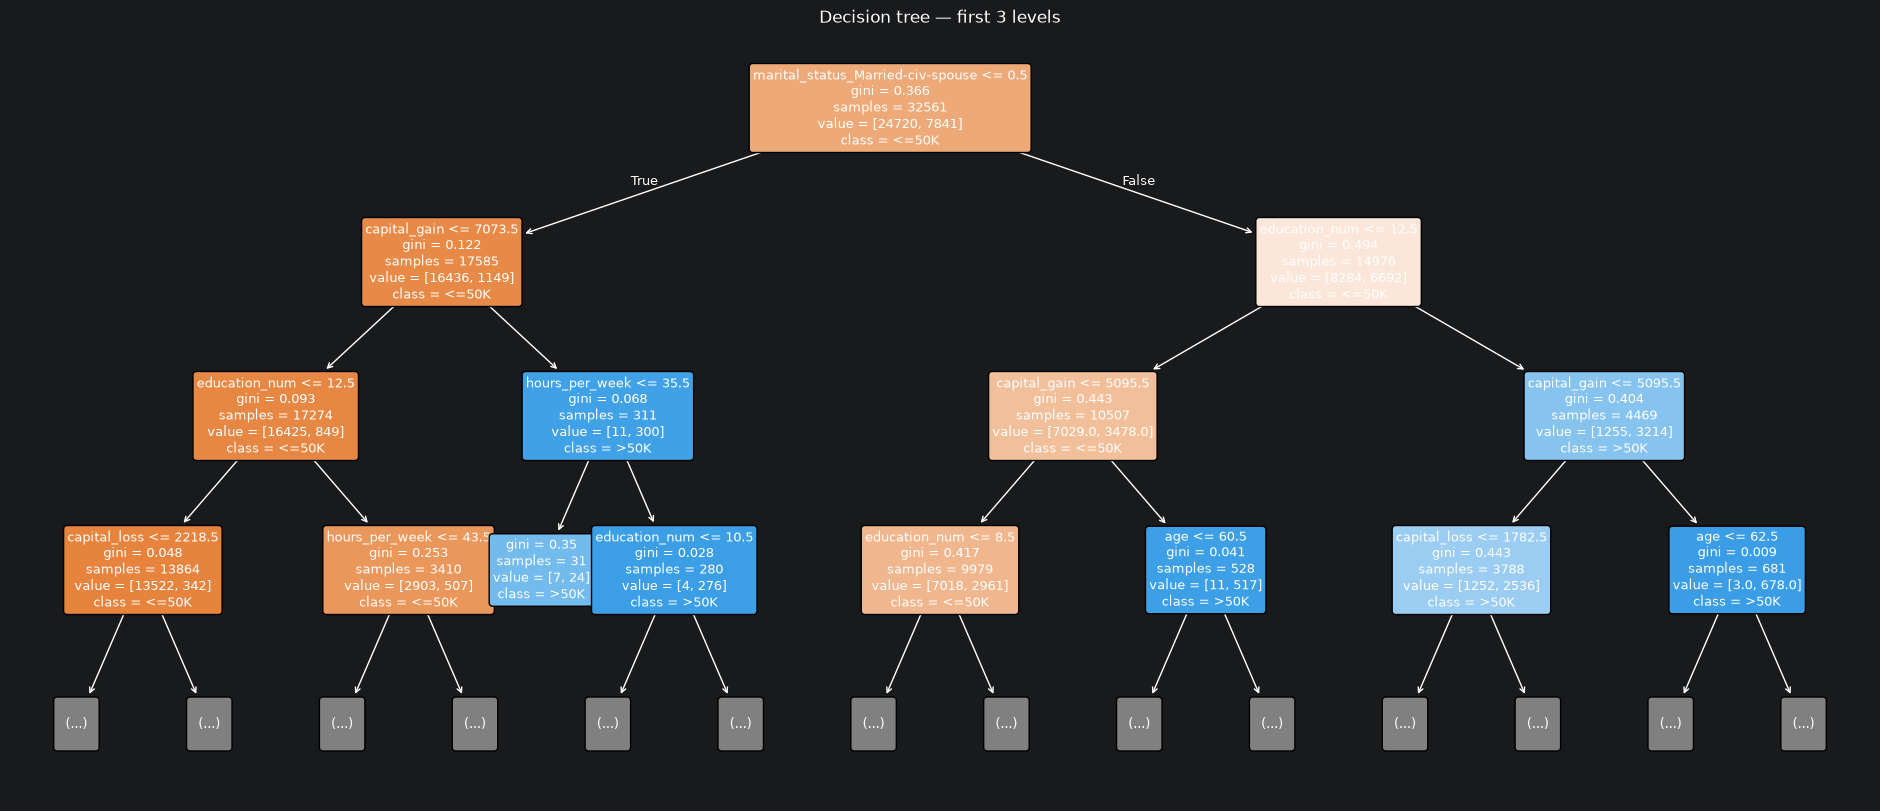

In [39]:
plt.figure(figsize=(24, 10))
plot_tree(
    final_tree,
    max_depth=3,
    feature_names=feature_names,
    class_names=["<=50K", ">50K"],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    fontsize=9
)
plt.title("Decision tree — first 3 levels")
plt.show()

## 6. (Optional) Decision rules induced from the decision tree

Every path from the root of the tree to a leaf is an **IF … THEN …** rule. The final tree has hundreds of leaves, and its rules are long (often 8–10 conditions), so they are hard to read. The rule-based classifier is built in four steps, similar to the classic C4.5rules method:

1. **Rule extraction:** one rule per leaf. Conditions on the same variable are merged (for example, `age > 30` and `age > 40` become `age > 40`), and 0/1 variables are written as `= 1` or `= 0`.
2. **Rule simplification:** each rule is shortened by removing conditions one at a time, as long as its **confidence** on the training data (the share of covered people in the predicted class) does not drop. This removes conditions the tree needed for other branches but that do not matter for this rule. Duplicate rules are then removed.
3. **Rule selection:** only rules predicting **>50K** are kept, with **support** (number of training people covered) ≥ `MIN_SUPPORT` and confidence ≥ `MIN_CONFIDENCE`.
4. **Classification:** IF a person matches at least one selected rule → **>50K**, ELSE → **≤50K** (the default, majority class).

Learning rules for the minority class with the majority class as default is a standard approach in rule induction (it is also how the RIPPER algorithm works). It gives a short, readable model: "these are the profiles of high earners; everyone else is predicted ≤50K".

In [40]:
binary_features = {f for f in feature_names if set(X_train[f].unique()) <= {0, 1}}
feature_index = {f: i for i, f in enumerate(feature_names)}

X_train_array = X_train.to_numpy(dtype=float)
X_test_array = X_test.to_numpy(dtype=float)
y_train_array = y_train.to_numpy()


def extract_rules(tree):
    """One rule per leaf, as a dict {feature: (lower, upper)} meaning lower < feature <= upper."""
    t = tree.tree_
    rules = []

    def walk(node, bounds):
        if t.children_left[node] == -1:          # leaf
            rules.append(dict(bounds))
            return
        feature = feature_names[t.feature[node]]
        threshold = t.threshold[node]
        lower, upper = bounds.get(feature, (-np.inf, np.inf))

        left = dict(bounds)                       # feature <= threshold
        left[feature] = (lower, min(upper, threshold))
        walk(t.children_left[node], left)

        right = dict(bounds)                      # feature > threshold
        right[feature] = (max(lower, threshold), upper)
        walk(t.children_right[node], right)

    walk(0, {})
    return rules


def rule_mask(bounds, X_array):
    """Boolean mask of the rows that satisfy all conditions of a rule."""
    mask = np.ones(len(X_array), dtype=bool)
    for feature, (lower, upper) in bounds.items():
        values = X_array[:, feature_index[feature]]
        mask &= (values > lower) & (values <= upper)
    return mask


def rule_quality(bounds):
    """Support and share of >50K among the training people covered by the rule."""
    covered = rule_mask(bounds, X_train_array)
    support = int(covered.sum())
    positive_share = y_train_array[covered].mean() if support > 0 else 0.0
    return support, positive_share


def condition_text(feature, lower, upper):
    if feature in binary_features:
        return f"{feature} = 1" if lower >= 0.5 else f"{feature} = 0"
    if lower == -np.inf:
        return f"{feature} <= {upper:.1f}"
    if upper == np.inf:
        return f"{feature} > {lower:.1f}"
    return f"{lower:.1f} < {feature} <= {upper:.1f}"


def rule_text(bounds):
    return " AND ".join(condition_text(f, lo, up) for f, (lo, up) in bounds.items())


raw_rules = extract_rules(final_tree)

print(f"Rules extracted from the tree (one per leaf): {len(raw_rules)}")
print(f"Average rule length: {np.mean([len(r) for r in raw_rules]):.2f} conditions")
print(f"\nExample of an unsimplified rule:\nIF {rule_text(raw_rules[len(raw_rules) // 2])}")

Rules extracted from the tree (one per leaf): 552
Average rule length: 9.50 conditions

Example of an unsimplified rule:
IF marital_status_Married-civ-spouse = 1 AND 9.5 < education_num <= 12.5 AND capital_gain <= 5095.5 AND capital_loss <= 1782.5 AND 26.5 < age <= 27.5 AND 35.5 < hours_per_week <= 53.5 AND workclass_Private = 1


#### Rule simplification

In [41]:
def simplify_rule(bounds, tolerance=0.005):
    """Greedily remove conditions while the rule's confidence does not drop (by more than the tolerance)."""
    support, positive_share = rule_quality(bounds)
    predicted_class = int(positive_share >= 0.5)
    confidence = positive_share if predicted_class == 1 else 1 - positive_share

    bounds = dict(bounds)
    while len(bounds) > 1:
        best = None
        for feature in bounds:
            shorter = {f: b for f, b in bounds.items() if f != feature}
            _, share = rule_quality(shorter)
            new_confidence = share if predicted_class == 1 else 1 - share
            if new_confidence >= confidence - tolerance and (best is None or new_confidence > best[1]):
                best = (shorter, new_confidence)
        if best is None:
            break
        bounds, confidence = best

    support, positive_share = rule_quality(bounds)
    confidence = positive_share if predicted_class == 1 else 1 - positive_share
    return bounds, predicted_class, support, confidence


simplified = []
seen = set()
for bounds in raw_rules:
    new_bounds, predicted_class, support, confidence = simplify_rule(bounds)
    key = tuple(sorted(new_bounds.items()))
    if key in seen:
        continue                                   # remove duplicate rules
    seen.add(key)
    simplified.append({
        "IF": rule_text(new_bounds),
        "THEN": ">50K" if predicted_class == 1 else "<=50K",
        "Predicted_class": predicted_class,
        "Support": support,
        "Confidence": confidence,
        "Length": len(new_bounds),
        "bounds": new_bounds,
    })

all_rules = pd.DataFrame(simplified)

print(f"Rules after simplification and removing duplicates: {len(all_rules)} (from {len(raw_rules)})")
print(f"Average rule length: {all_rules['Length'].mean():.2f} conditions (was {np.mean([len(r) for r in raw_rules]):.2f})")
print(f"  rules predicting >50K:  {(all_rules['Predicted_class'] == 1).sum()}")
print(f"  rules predicting <=50K: {(all_rules['Predicted_class'] == 0).sum()}")

Rules after simplification and removing duplicates: 411 (from 552)
Average rule length: 4.64 conditions (was 9.50)
  rules predicting >50K:  119
  rules predicting <=50K: 292


#### Rule selection and the rule-based classifier

In [42]:
MIN_SUPPORT = 50          # a rule must cover at least 50 training people
MIN_CONFIDENCE = 0.65     # and be correct for at least 65% of them

selected_rules = (all_rules[(all_rules["Predicted_class"] == 1)
                            & (all_rules["Support"] >= MIN_SUPPORT)
                            & (all_rules["Confidence"] >= MIN_CONFIDENCE)]
                  .sort_values(["Confidence", "Support"], ascending=False)
                  .reset_index(drop=True))
selected_rules.index = selected_rules.index + 1
selected_rules.index.name = "Rule"

print(f"Selected rules (all predict >50K): {len(selected_rules)}")
print(f"Average rule length: {selected_rules['Length'].mean():.2f} conditions")
print("Default class when no rule matches: <=50K")


def rule_classifier(X_array, rules):
    """Returns predictions, a >50K probability, and the number of the first matching rule (0 = none)."""
    first_rule = np.zeros(len(X_array), dtype=int)
    probability = np.full(len(X_array), np.nan)
    for rule_number, rule in rules.iterrows():
        new_match = (first_rule == 0) & rule_mask(rule["bounds"], X_array)
        first_rule[new_match] = rule_number
        probability[new_match] = rule["Confidence"]
    predictions = (first_rule > 0).astype(int)
    return predictions, probability, first_rule


# Probability for people not covered by any rule = share of >50K among uncovered training people
train_pred_rules, _, _ = rule_classifier(X_train_array, selected_rules)
uncovered_rate = y_train_array[train_pred_rules == 0].mean()

y_pred_rules, y_prob_rules, matched_rule = rule_classifier(X_test_array, selected_rules)
y_prob_rules = np.where(np.isnan(y_prob_rules), uncovered_rate, y_prob_rules)

print(f"\nTest people matched by at least one rule (predicted >50K): {(matched_rule > 0).mean() * 100:.2f}%")

Selected rules (all predict >50K): 104
Average rule length: 4.75 conditions
Default class when no rule matches: <=50K

Test people matched by at least one rule (predicted >50K): 25.97%


#### The strongest rules

In [43]:
pd.set_option("display.max_colwidth", None)

display(selected_rules[["IF", "THEN", "Support", "Confidence", "Length"]].head(15).round(3))

,IF,THEN,Support,Confidence,Length
Rule,,,,,
1,marital_status_Married-civ-spouse = 1 AND 5095.5 < capital_gain <= 28167.0 AND age <= 60.5,>50K,943,1.000,3
2,marital_status_Married-civ-spouse = 1 AND education_num > 12.5 AND 1782.5 < capital_loss <= 1989.5 AND 31.5 < age <= 50.5,>50K,227,1.000,4
3,marital_status_Married-civ-spouse = 1 AND education_num > 12.5 AND 1782.5 < capital_loss <= 1989.5 AND workclass_Private = 1,>50K,202,1.000,4
4,marital_status_Married-civ-spouse = 1 AND 1939.5 < capital_loss <= 1989.5,>50K,168,1.000,2
5,capital_gain > 7073.5 AND hours_per_week > 35.5 AND marital_status_Never-married = 1,>50K,131,1.000,3
6,education_num > 12.5 AND capital_loss > 2403.5,>50K,63,1.000,2
7,capital_gain > 7073.5 AND education_num > 10.5,>50K,925,0.998,2
8,marital_status_Married-civ-spouse = 1 AND capital_gain > 5095.5 AND age <= 62.5,>50K,1089,0.997,3
9,marital_status_Married-civ-spouse = 1 AND education_num > 12.5 AND capital_gain > 5095.5,>50K,681,0.996,3


#### Example: classifying individual people with the rules

In [44]:
# 3 people matched by a rule and 3 people not matched by any rule
examples = pd.concat([
    X_test[matched_rule > 0].sample(3, random_state=RANDOM_STATE),
    X_test[matched_rule == 0].sample(3, random_state=RANDOM_STATE)
])

for index, person in examples.iterrows():
    prediction, _, rule_number = rule_classifier(person.to_numpy(dtype=float).reshape(1, -1), selected_rules)
    actual = ">50K" if y_test[index] == 1 else "<=50K"
    predicted = ">50K" if prediction[0] == 1 else "<=50K"
    print(f"Person {index}: actual = {actual}, predicted = {predicted}")
    if rule_number[0] > 0:
        rule = selected_rules.loc[rule_number[0]]
        print(f"   Rule {rule_number[0]}: IF {rule['IF']} THEN >50K (confidence {rule['Confidence']:.2f})\n")
    else:
        print("   No rule matched -> default class <=50K\n")

Person 6816: actual = <=50K, predicted = >50K
   Rule 37: IF marital_status_Married-civ-spouse = 1 AND 12.5 < education_num <= 14.5 AND 31.0 < hours_per_week <= 57.0 AND 36.5 < age <= 39.5 AND occupation_Prof-specialty = 1 AND workclass_Private = 1 THEN >50K (confidence 0.87)

Person 7274: actual = <=50K, predicted = >50K
   Rule 102: IF marital_status_Married-civ-spouse = 1 AND 48.5 < age <= 50.5 AND occupation_Other-service = 0 AND occupation_Farming-fishing = 0 AND occupation_Craft-repair = 0 AND occupation_Machine-op-inspct = 0 THEN >50K (confidence 0.66)

Person 8827: actual = <=50K, predicted = >50K
   Rule 65: IF marital_status_Married-civ-spouse = 1 AND education_num > 12.5 AND 41.5 < age <= 59.5 AND occupation_Sales = 0 AND occupation_Other-service = 0 AND workclass_Self-emp-not-inc = 0 THEN >50K (confidence 0.81)

Person 4533: actual = <=50K, predicted = <=50K
   No rule matched -> default class <=50K

Person 9290: actual = <=50K, predicted = <=50K
   No rule matched -> defau

#### Comparison: decision tree vs. decision rule-based classifier

In [45]:
rule_metrics = classification_metrics(y_test, y_pred_rules, y_prob_rules)

comparison = pd.DataFrame([tree_metrics, rule_metrics],
                          index=["Decision tree", "Rule-based classifier"])

comparison["Model size"] = [f"{final_tree.get_n_leaves()} leaves", f"{len(selected_rules)} rules"]
comparison["Avg. conditions per rule"] = [np.mean([len(r) for r in raw_rules]), selected_rules["Length"].mean()]

display(comparison.round(4))

agreement = (y_pred_tree == y_pred_rules).mean()
print(f"The two classifiers give the same prediction for {agreement * 100:.2f}% of test observations.")

C:\Users\gabij\PycharmProjects\WelcomeScreen\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


,Accuracy,Precision,Recall,F1-score,ROC-AUC,Model size,Avg. conditions per rule
Decision tree,0.8119,0.0,0.0,0.0,NaN,552 leaves,9.5036
Rule-based classifier,0.7403,0.0,0.0,0.0,NaN,104 rules,4.7500


The two classifiers give the same prediction for 92.29% of test observations.


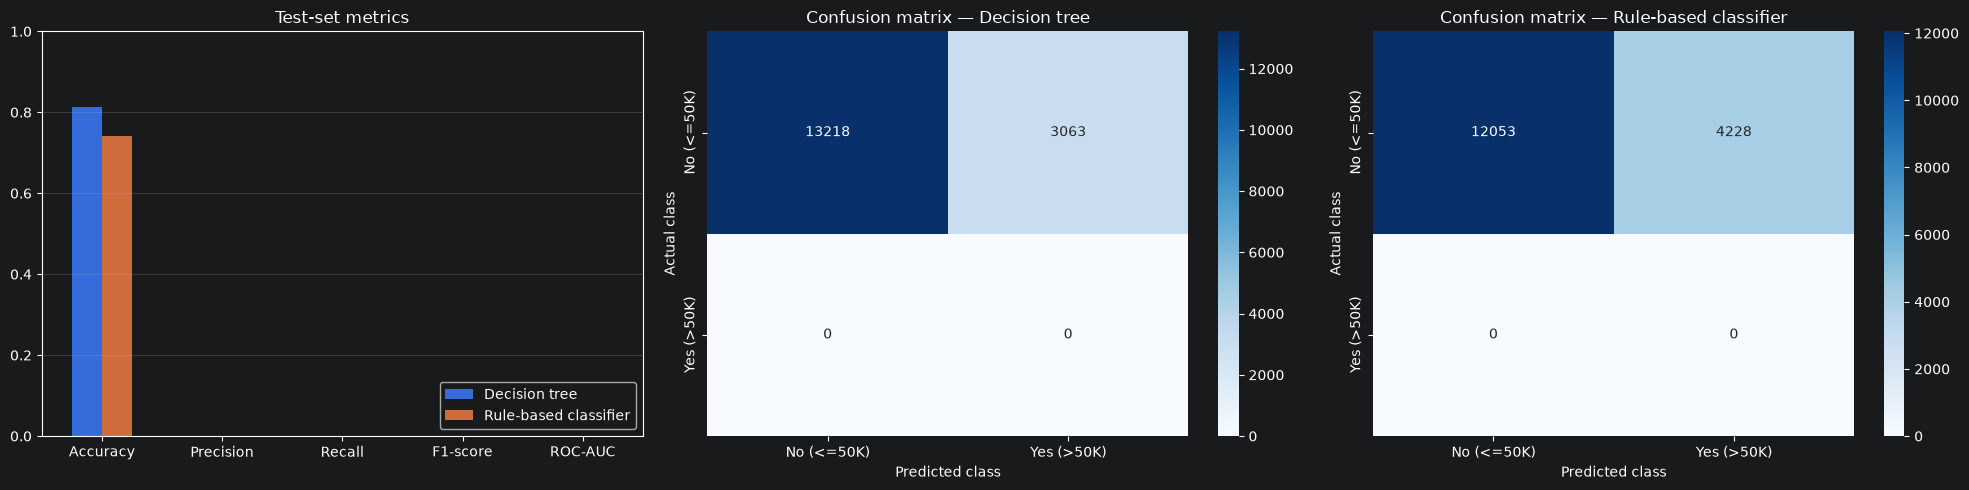

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

metric_names = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
comparison[metric_names].astype(float).T.plot(kind="bar", ax=axes[0], rot=0)
axes[0].set_ylim(0, 1)
axes[0].set_title("Test-set metrics")
axes[0].grid(True, axis="y", alpha=0.3)
axes[0].legend(loc="lower right")

for ax, predictions, title in [
    (axes[1], y_pred_tree, "Decision tree"),
    (axes[2], y_pred_rules, "Rule-based classifier"),
]:
    sns.heatmap(confusion_matrix(y_test, predictions, labels=[0, 1]), annot=True, fmt="d", cmap="Blues",
                xticklabels=["No (<=50K)", "Yes (>50K)"], yticklabels=["No (<=50K)", "Yes (>50K)"], ax=ax)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Actual class")
    ax.set_title(f"Confusion matrix — {title}")

plt.tight_layout()
plt.show()

**How to interpret the comparison:**

- **Model size and readability:** the rule-based classifier needs far fewer rules than the tree has leaves, and each rule has fewer conditions, so it is much easier to explain.
- **Accuracy vs. recall:** the rule set usually has slightly lower accuracy than the tree but finds more of the >50K people (higher recall), because rules are judged on their own and a person only needs to match one of them. The F1-scores are usually close.
- **ROC-AUC:** the tree gives a probability for every leaf, while the rule set only distinguishes "matched rule X" from "no rule matched", so its probability ranking is coarser and its ROC-AUC is usually lower.
- **Trade-off:** raising `MIN_CONFIDENCE` or `MIN_SUPPORT` gives fewer, more reliable rules (higher precision, lower recall). Lowering them finds more high earners but adds more false alarms.